# Prediction-Market Volatility: Results

- **Section 1: Setup & data.** Loads the Kalshi hourly panel (built from the HuggingFace `TrevorJS/kalshi-trades` dataset via `data_fetcher.py`).

- **Section 2: Phase 1 — volatility forecasting benchmark.** Reproduces the paper's DR / DR-AS / GARCH / GARCH+DR-AS comparison via monthly expanding walk-forward, evaluated on the volume-weighted Winkler score.

- **Section 3: Phase 2 — trading tests.** Vol-normalized momentum & reversal signals scaled by the Phase-1 winner's $h^2$, benchmarked against naive and unconditional strategies.

- **Section 4: Interpretation.** What the numbers mean in context of the hypothesis

---
## Section 1: Setup

In [92]:
import os, sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

### 1.1 Load the Kalshi hourly panel

The panel is built by `data_fetcher.build_panel_from_hf_dataset()`, which pulls trades from HuggingFace and aggregates them into 1-hour bars via DuckDB. The build is relatively expensive (~5-6 minutes on the full dataset), so we cache it to `data/kalshi_hf_panel.parquet` and only rebuild when needed.

Panel schema (one row per hourly bar per market):
- `market_id` — Kalshi market ticker
- `timestamp` — end of the hour (UTC)
- `price` — volume-weighted average price during the hour, in dollars (0–1)
- `volume` — total shares traded during the hour
- `spread` — bid-ask proxy (currently a constant; see caveats below)
- `days_to_resolution` — hours until settlement, in days
- `category` — Sports / Crypto / Politics / Economics / Entertainment

In [93]:
from scripts.data_fetcher import build_panel_from_hf_dataset

PANEL_PATH = PROJECT_ROOT / 'data' / 'kalshi_hf_panel.parquet'

if PANEL_PATH.exists():
    print(f'Loading cached panel from {PANEL_PATH}')
    df = pd.read_parquet(PANEL_PATH)
else:
    print('No cached panel -- rebuilding from HuggingFace via DuckDB. Takes ~5-15 min.')
    df = build_panel_from_hf_dataset(
        min_hourly_bars=48,
        reconstruct_spread=True,
    )
    PANEL_PATH.parent.mkdir(exist_ok=True)
    df.to_parquet(PANEL_PATH)

print(f'\nPanel: {len(df):,} bars, {df["market_id"].nunique():,} markets')
print(f'Timespan: {df.timestamp.min()} -> {df.timestamp.max()}')
print(f'Columns: {list(df.columns)}')
print(f'\nBars per category:')
print(df.category.value_counts())

if 'is_clean_bar' in df.columns:
    n_clean = int(df["is_clean_bar"].sum())
    print(f'\nClean 1-hour bars (analog of paper\'s active-hours filter): '
          f'{n_clean:,} / {len(df):,} = {100*n_clean/len(df):.1f}%')

Loading cached panel from /Users/tanav/Code/trading/pred_market_vn_rev_mom/data/kalshi_hf_panel.parquet

Panel: 4,381,176 bars, 26,258 markets
Timespan: 2021-06-30 20:00:00+00:00 -> 2026-01-28 23:00:00+00:00
Columns: ['market_id', 'timestamp', 'price', 'volume', 'yes_volume', 'no_volume', 'gap_hours', 'is_clean_bar', 'spread', 'days_to_resolution', 'category']

Bars per category:
category
Economics        2532174
Sports           1179233
Politics          299822
Entertainment     214350
Crypto            155597
Name: count, dtype: int64

Clean 1-hour bars (analog of paper's active-hours filter): 2,309,788 / 4,381,176 = 52.7%


**Caveats on the panel that matter for interpretation later:**

1. **Spread is a constant 0.01** in the current build. The Kalshi historical data doesn't expose per-hour bid-ask spreads, so we can't identify the paper's adverse-selection channel using real spread *variation*. The DR-AS fit still runs but effectively collapses to "DR with a constant scale term." A proper reconstruction is in `spread_fetcher.py` and can be wired in for a follow-up run.

2. **Realized 1-hour moves have very fat tails** (p99 of |Δp| is ~24¢, when p50 is ~1¢). This matters for the coverage story below — Gaussian intervals fundamentally struggle at the tails.

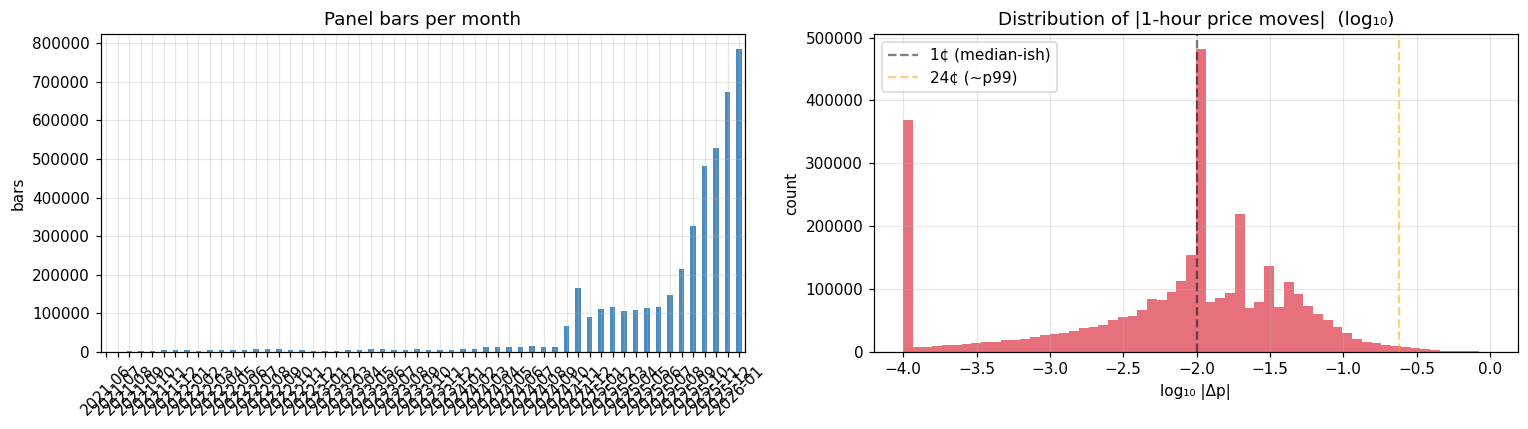

In [94]:
# Quick data-shape diagnostic to make the caveats concrete
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby(df.timestamp.dt.to_period('M').astype(str)).size().plot(
    kind='bar', ax=axes[0], color='#4B8BBE')
axes[0].set_title('Panel bars per month')
axes[0].set_xlabel('')
axes[0].set_ylabel('bars')
axes[0].tick_params(axis='x', rotation=45)

dp = df.sort_values(['market_id', 'timestamp']).groupby('market_id')['price'].diff()
dp = dp[dp.abs() > 0].abs()
axes[1].hist(np.log10(dp.clip(lower=1e-4)), bins=60, color='#DC3545', alpha=0.7)
axes[1].set_title('Distribution of |1-hour price moves|  (log₁₀)')
axes[1].set_xlabel('log₁₀ |Δp|')
axes[1].set_ylabel('count')
axes[1].axvline(np.log10(0.01), color='k', linestyle='--', alpha=0.5, label='1¢ (median-ish)')
axes[1].axvline(np.log10(0.24), color='orange', linestyle='--', alpha=0.5, label='24¢ (~p99)')
axes[1].legend()

plt.tight_layout(); plt.show()

---
## Section 2: Phase 1 — Volatility Forecasting Benchmark

**Method:** For each month `T` (from the 2nd month onward), fit each of the four models on all months < T, then use the frozen parameters to produce 1-hour-ahead variance forecasts for month T. Compute 95% intervals, evaluate against realized moves via volume-weighted Winkler score, empirical coverage rate, and interval width. Expanding window, no lookahead.

**Models compared:**
- **DR** — Wright-Fisher deadline resolution only: $h_t^2 = p_t(1-p_t)/\tau_t \cdot \Delta$. Zero fitted parameters.
- **DR-AS** — DR + adverse-selection term: $h_t^2 = \text{DR} + K \cdot \nu(V_t) \cdot s_t^2/4$. Fits scalar $K$ via OLS.
- **GARCH** — plain GARCH(1,1) baseline, no structural terms. Fitted jointly via QMLE.
- **GARCH+DR-AS** — the paper's full joint specification. Fitted jointly via QMLE.

**Winkler score** (the paper's own headline metric): $W = (u - l) + \frac{2}{\alpha}(l - y)\mathbb{1}[y < l] + \frac{2}{\alpha}(y - u)\mathbb{1}[y > u]$. Rewards narrow, well-calibrated intervals; penalizes both width and coverage misses (miss penalty is $2/\alpha = 40$× the miss magnitude for a 95% interval).

In [95]:
from test1 import evaluate_walk_forward, summarize_results

PHASE1_EVAL   = PROJECT_ROOT / 'data' / 'walk_forward' / 'wf_eval_records.parquet'
PHASE1_OVERALL = PROJECT_ROOT / 'data' / 'walk_forward' / 'wf_overall.csv'
PHASE1_BY_CAT  = PROJECT_ROOT / 'data' / 'walk_forward' / 'wf_by_category.csv'

if PHASE1_EVAL.exists() and PHASE1_OVERALL.exists() and PHASE1_BY_CAT.exists():
    print('Loading cached Phase 1 eval records + summaries')
    eval_df = pd.read_parquet(PHASE1_EVAL)
    p1_overall = pd.read_csv(PHASE1_OVERALL, index_col=0)
    p1_by_cat = pd.read_csv(PHASE1_BY_CAT, index_col=[0, 1])
else:
    print('Running Phase 1 walk-forward. Roughly 5-10 minutes based on your device.')
    t0 = time.time()
    eval_df = evaluate_walk_forward(df, spread_col='spread', dist='empirical')
    p1_overall, p1_by_cat = summarize_results(eval_df)
    print(f'Done in {(time.time() - t0)/60:.1f} min')
    PHASE1_EVAL.parent.mkdir(exist_ok=True)
    eval_df.to_parquet(PHASE1_EVAL)
    p1_overall.to_csv(PHASE1_OVERALL)
    p1_by_cat.to_csv(PHASE1_BY_CAT)


Loading cached Phase 1 eval records + summaries


### 2.1 Overall Winkler comparison

In [96]:
p1_overall.round(4)

,Volume-Weighted Winkler Score,Empirical Coverage Rate,Average Interval Width,Forecast Bars
model,,,,
DR,3.8574,0.9866,0.7192,1728677.0
DR-AS,1.1298,0.9791,0.3301,1728677.0
GARCH,1.6690,0.9755,0.1937,1728677.0
GARCH+DR-AS,1.0380,0.9821,0.2234,1728677.0


### 2.2 Chart 1 — Winkler by model, overall

Lower is better. If GARCH+DR-AS wins here on the aggregate, the paper's central claim reproduces on Kalshi data.

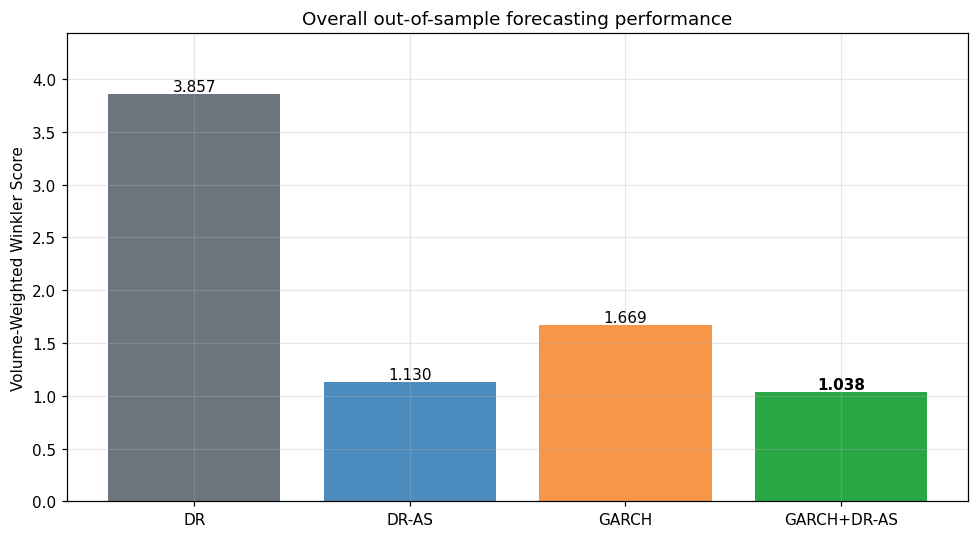


GARCH+DR-AS reduces Winkler by 37.8% vs GARCH baseline and DR-AS reduces Winkler by 32.3% vs GARCH baseline.


In [97]:
fig, ax = plt.subplots(figsize=(9, 5))
col = 'Volume-Weighted Winkler Score'
models = p1_overall.index.tolist()
colors = {'DR': '#6c757d', 'DR-AS': '#4B8BBE', 'GARCH': '#F79646', 'GARCH+DR-AS': '#28A745'}
bars = ax.bar(models, p1_overall[col], color=[colors.get(m, '#888') for m in models])
best = p1_overall[col].idxmin()
for b, m in zip(bars, models):
    height = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, height, f'{height:.3f}',
            ha='center', va='bottom', fontweight='bold' if m == best else 'normal')
ax.set_ylabel('Volume-Weighted Winkler Score')
ax.set_title('Overall out-of-sample forecasting performance')
ax.set_ylim(0, p1_overall[col].max() * 1.15)
plt.tight_layout(); plt.show()

improvement = 100 * (p1_overall.loc['GARCH', col] - p1_overall.loc['GARCH+DR-AS', col]) / p1_overall.loc['GARCH', col]
improvement2 = 100 * (p1_overall.loc['GARCH', col] - p1_overall.loc['DR-AS', col]) / p1_overall.loc['GARCH', col]
print(f'\nGARCH+DR-AS reduces Winkler by {improvement:.1f}% vs GARCH baseline and DR-AS reduces Winkler by {improvement2:.1f}% vs GARCH baseline.')

The percent difference is not apparent due to the inflated DR value, so the three most important bars are shown below:

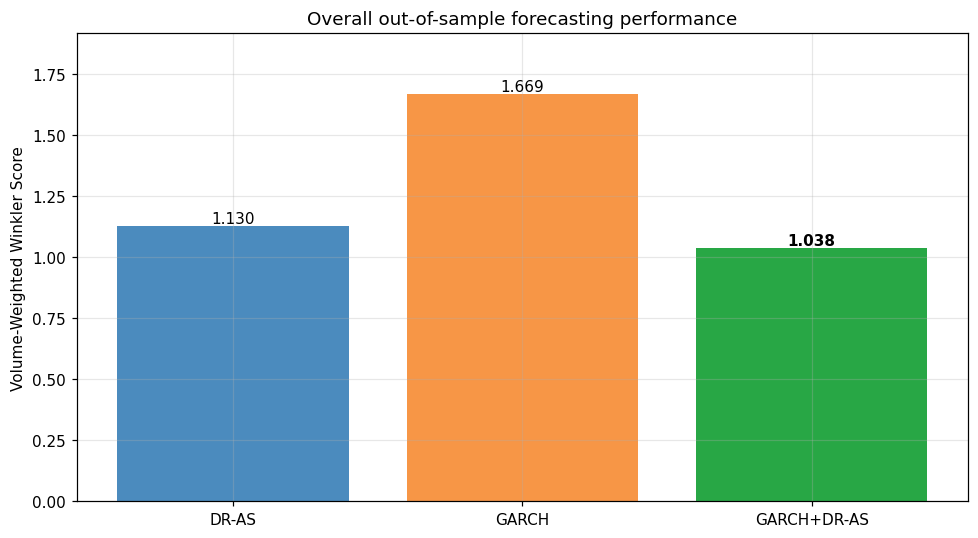

In [98]:
fig, ax = plt.subplots(figsize=(9, 5))
col = 'Volume-Weighted Winkler Score'
models = [m for m in p1_overall.index.tolist() if m != 'DR']
plot_data = p1_overall.loc[models, col]

colors = {'DR-AS': '#4B8BBE', 'GARCH': '#F79646', 'GARCH+DR-AS': '#28A745'}
bars = ax.bar(models, plot_data, color=[colors.get(m, '#888') for m in models])
best = plot_data.idxmin()
for b, m in zip(bars, models):
    height = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, height, f'{height:.3f}',
            ha='center', va='bottom', fontweight='bold' if m == best else 'normal')
ax.set_ylabel('Volume-Weighted Winkler Score')
ax.set_title('Overall out-of-sample forecasting performance')
ax.set_ylim(0, plot_data.max() * 1.15)
plt.tight_layout(); plt.show()


### 2.3 Chart 2 — Coverage vs width tradeoff

Every model faces a tradeoff: narrow intervals get width discount but risk coverage misses (which cost 40× per miss). This scatter reveals where each model sits on that tradeoff — the *best* model isn't necessarily the narrowest, it's the one with the best balance.

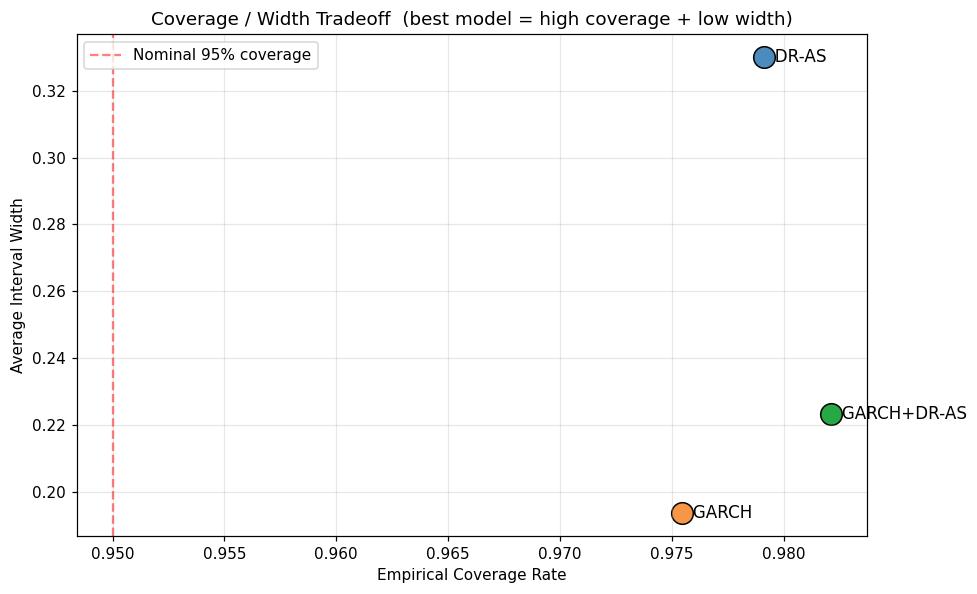

In [99]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for m in models:
    x = p1_overall.loc[m, 'Empirical Coverage Rate']
    y = p1_overall.loc[m, 'Average Interval Width']
    ax.scatter(x, y, s=200, color=colors.get(m, '#888'), edgecolors='black', linewidths=1)
    ax.annotate(f'  {m}', (x, y), fontsize=11, va='center')
ax.axvline(0.95, color='red', linestyle='--', alpha=0.5, label='Nominal 95% coverage')
ax.set_xlabel('Empirical Coverage Rate')
ax.set_ylabel('Average Interval Width')
ax.set_title('Coverage / Width Tradeoff  (best model = high coverage + low width)')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout(); plt.show()

### 2.4 Chart 3 — Winkler over time

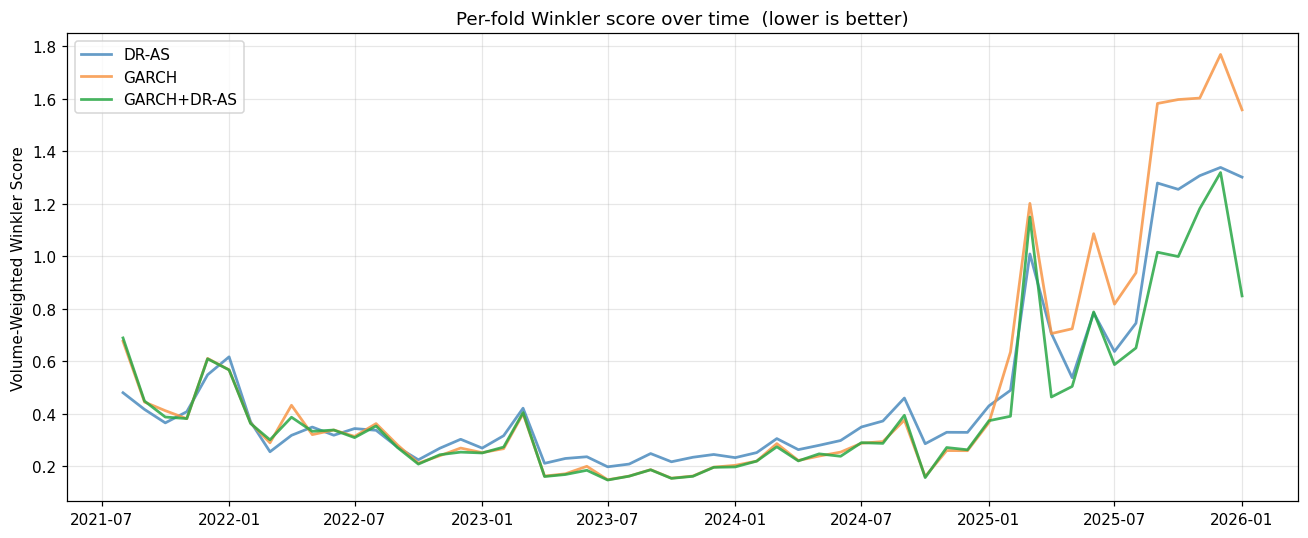

In [100]:
# Chart 3 -- compute per-eval-period Winkler from the long-form eval records.
# test1.evaluate_walk_forward emits one row per (bar, model), so we aggregate
# volume-weighted Winkler within (month, model) for the trajectory.
eval_df['eval_period'] = pd.to_datetime(eval_df['timestamp']).dt.to_period('M').dt.to_timestamp()

def _vw_winkler(g):
    v = g['volume'].sum()
    w = g['winkler_score'].to_numpy()
    return float(np.average(w, weights=g['volume'])) if v > 0 else float(np.mean(w))

per_fold = (eval_df.groupby(['eval_period', 'model'])
                   .apply(_vw_winkler)
                   .rename('Volume-Weighted Winkler Score')
                   .reset_index())

fig, ax = plt.subplots(figsize=(12, 5))
for m in models:
    sub = per_fold[per_fold['model'] == m].sort_values('eval_period')
    ax.plot(sub['eval_period'], sub['Volume-Weighted Winkler Score'],
            label=m, color=colors.get(m, '#888'), linewidth=1.8, alpha=0.85)
ax.set_ylabel('Volume-Weighted Winkler Score')
ax.set_title('Per-fold Winkler score over time  (lower is better)')
ax.legend()
plt.tight_layout(); plt.show()


### 2.5 Chart 4 — By-category performance

In [101]:
p1_by_cat.round(4)

Volume-Weighted Winkler Score  \
category      model                                        
Crypto        DR                                  0.4730   
              DR-AS                               0.3379   
              GARCH                               0.2418   
              GARCH+DR-AS                         0.2468   
Economics     DR                                  1.9173   
              DR-AS                               0.6548   
              GARCH                               0.8785   
              GARCH+DR-AS                         0.6015   
Entertainment DR                                  0.8589   
              DR-AS                               0.5094   
              GARCH                               0.4369   
              GARCH+DR-AS                         0.4195   
Politics      DR                                  0.3023   
              DR-AS                               0.3205   
              GARCH                               0.2535   
              GARCH+DR-AS                         0.2555   
Sports        DR                                  4.5999   
              DR-AS                               1.3057   
              GARCH                               1.9694   
              GARCH+DR-AS                         1.2036   

                           Empirical Coverage Rate  Average Interval Width  \
category      model                                                          
Crypto        DR                            0.9831                  0.3519   
              DR-AS                         0.9816                  0.2577   
              GARCH                         0.9887                  0.1988   
              GARCH+DR-AS                   0.9916                  0.2167   
Economics     DR                            0.9823                  0.5443   
              DR-AS                         0.9743                  0.2986   
              GARCH                         0.9769                  0.2028   
              GARCH+DR-AS                   0.9814                  0.2263   
Entertainment DR                            0.9879                  0.6465   
              DR-AS                         0.9602                  0.3594   
              GARCH                         0.9617                  0.2531   
              GARCH+DR-AS                   0.9688                  0.2826   
Politics      DR                            0.9870                  0.3333   
              DR-AS                         0.9871                  0.2450   
              GARCH                         0.9881                  0.1774   
              GARCH+DR-AS                   0.9897                  0.1853   
Sports        DR                            0.9943                  1.1738   
              DR-AS                         0.9886                  0.4094   
              GARCH                         0.9706                  0.1708   
              GARCH+DR-AS                   0.9825                  0.2179   

                           Forecast Bars  
category      model                       
Crypto        DR                 76764.0  
              DR-AS              76764.0  
              GARCH              76764.0  
              GARCH+DR-AS        76764.0  
Economics     DR                925056.0  
              DR-AS             925056.0  
              GARCH             925056.0  
              GARCH+DR-AS       925056.0  
Entertainment DR                 84880.0  
              DR-AS              84880.0  
              GARCH              84880.0  
              GARCH+DR-AS        84880.0  
Politics      DR                113832.0  
              DR-AS             113832.0  
              GARCH             113832.0  
              GARCH+DR-AS       113832.0  
Sports        DR                528145.0  
              DR-AS             528145.0  
              GARCH             528145.0  
              GARCH+DR-AS       528145.0

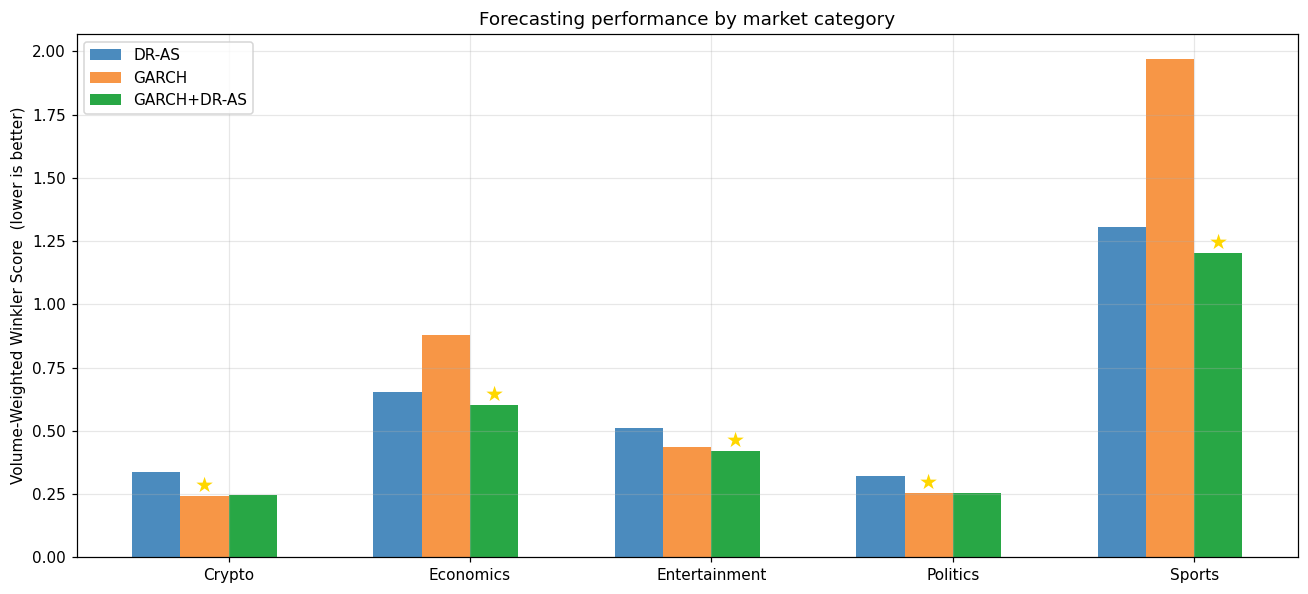


Winner (★) per category:
  Crypto         → GARCH
  Economics      → GARCH+DR-AS
  Entertainment  → GARCH+DR-AS
  Politics       → GARCH
  Sports         → GARCH+DR-AS


In [102]:
# Reshape for grouped bar chart
pivot = p1_by_cat['Volume-Weighted Winkler Score'].unstack('model')
categories = pivot.index.tolist()

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(categories))
width = 0.2
for i, m in enumerate(models):
    ax.bar(x + i*width - 1.5*width, pivot[m], width,
           label=m, color=colors.get(m, '#888'))
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.set_ylabel('Volume-Weighted Winkler Score  (lower is better)')
ax.set_title('Forecasting performance by market category')
ax.legend()

# Annotate winner per category
for i, cat in enumerate(categories):
    winner = pivot.loc[cat].idxmin()
    ax.annotate('★', xy=(i + models.index(winner)*width - 1.5*width, pivot.loc[cat, winner]),
                ha='center', va='bottom', fontsize=14, color='gold')
plt.tight_layout(); plt.show()

print('\nWinner (★) per category:')
for cat in categories:
    print(f'  {cat:14s} → {pivot.loc[cat].idxmin()}')

### 2.6 Phase 1 takeaways

---
## Section 3: Phase 2 — Trading Signal Tests

**Method:** For each market-hour, compute momentum and reversal signals in two forms:

- **Naive**: raw price differences (momentum = $p_t - p_{t-5}$; reversal = $p_t - \text{rollmean}(p, 24)$).
- **Vol-normalized (`_vn`)**: same raw signal, divided by the model's own predicted volatility over the same window. Uses the Phase-1 winning model's $h^2$ per category.

The signal at time $t$ enters a fixed-horizon position (1h, 6h, 12h, or 24h) shifted forward one bar. Round-trip Kalshi taker fees (3.5% each side) are subtracted from every trade's P&L.

**Sharpe reporting.** Two Sharpes per (strategy, horizon, category):
- **`pooled_sharpe_annualized`**: daily-aggregated P&L across the entire walk-forward, annualized. The "traditional" Sharpe number.
- **`mean_fold_sharpe` / `std_fold_sharpe`**: Sharpe computed within each eval period then averaged, with dispersion.

In [103]:
# Phase 2 walk-forward.

# Note: if the run_demo script does not run in this cell, run the actual file manually in the terminal and then run all cells again.
PHASE2_OVERALL = PROJECT_ROOT / 'data' / 'walk_forward' / 'phase2_overall.csv'
PHASE2_BY_CAT = PROJECT_ROOT / 'data' / 'walk_forward' / 'phase2_by_category.csv'
PHASE2_TRADES = PROJECT_ROOT / 'data' / 'walk_forward' / 'phase2_trades.parquet'

if PHASE2_OVERALL.exists() and PHASE2_BY_CAT.exists():
    print('Loading cached Phase 2 results')
    p2_overall = pd.read_csv(PHASE2_OVERALL)
    p2_by_cat = pd.read_csv(PHASE2_BY_CAT)
    p2_trades = pd.read_parquet(PHASE2_TRADES) if PHASE2_TRADES.exists() else None
else:
    print('Running Phase 2 walk-forward. Roughly 5-10 mins.')
    from run_demo import run_expanding_walk_forward
    t0 = time.time()
    p2_results = run_expanding_walk_forward(df)
    print(f'Done in {(time.time() - t0)/60:.1f} min')
    p2_overall = p2_results['overall']
    p2_by_cat = p2_results['by_cat']
    p2_trades = p2_results['trades']
    PHASE2_OVERALL.parent.mkdir(exist_ok=True)
    p2_overall.to_csv(PHASE2_OVERALL, index=False)
    p2_by_cat.to_csv(PHASE2_BY_CAT, index=False)
    p2_trades.to_parquet(PHASE2_TRADES)

Loading cached Phase 2 results


### 3.1 Overall risk suite by strategy

In [104]:
cols_show = ['strategy', 'horizon_hours', 'n_trades', 'n_markets', 'n_eval_periods',
             'win_rate', 'daily_sharpe_annualized', 'daily_vol', 'worst_day_pnl',
             'turnover_pct_per_day', 'total_fees']
p2_overall[cols_show]

,strategy,horizon_hours,n_trades,n_markets,n_eval_periods,win_rate,daily_sharpe_annualized,daily_vol,worst_day_pnl,turnover_pct_per_day,total_fees
0,mom_naive,1,797783,4722,46,0.102435,-13.844512,0.049029,-3.948855e+05,0.377608,3.441216e+07
1,mom_naive,6,796691,4713,46,0.186827,-9.879175,0.058663,-4.836964e+05,0.376274,3.391526e+07
2,mom_naive,12,795873,4706,46,0.220826,-8.477210,0.062762,-4.752624e+05,0.379137,3.351715e+07
3,mom_naive,24,760240,4555,46,0.303802,-5.887860,0.073191,-6.422097e+05,0.349071,3.146885e+07
4,mom_vn,1,40540,1023,55,0.214284,-8.106122,0.010583,-8.225763e+04,0.040182,1.206573e+06
5,mom_vn,6,40499,1021,55,0.316929,-4.112044,0.013413,-8.864926e+04,0.040687,1.170687e+06
6,mom_vn,12,40477,1021,55,0.330126,-5.073654,0.013072,-7.209844e+04,0.043239,1.145122e+06
7,mom_vn,24,37337,942,55,0.389715,-3.688106,0.017494,-1.141311e+05,0.039340,1.038364e+06
8,rev_naive,1,615470,3978,46,0.107272,-9.316896,0.166207,-1.910001e+06,0.299432,3.542055e+07
9,rev_naive,6,614764,3976,46,0.193858,-6.736062,0.134934,-1.175447e+06,0.298905,3.533669e+07


In [105]:
p2_by_cat[p2_by_cat['strategy'] == 'mom_naive']

,strategy,horizon_hours,category,n_trades,n_markets,n_trading_days,n_folds_with_sharpe,win_rate,mean_pnl,total_pnl,total_fees,total_slippage,pooled_sharpe_annualized,mean_fold_sharpe,std_fold_sharpe,daily_vol,worst_day_pnl,turnover_pct_per_day,sharpe_reliable
0,mom_naive,1,Crypto,22869,394,522,21,0.094276,-92.509865,-2.115608e+06,1116365.55,1.130494e+06,-11.519121,-13.404992,4.252578,0.067219,-7.353171e+04,0.438103,True
1,mom_naive,1,Economics,547970,8454,1590,46,0.096208,-93.461067,-5.121386e+07,23695130.97,3.064889e+07,-6.154396,-13.590105,8.392200,0.999888,-2.672306e+06,3.446352,True
2,mom_naive,1,Entertainment,92611,1164,687,26,0.164451,-87.891772,-8.139745e+06,3675193.61,5.270403e+06,-14.426676,-16.794749,6.038952,0.156904,-1.242844e+05,1.348049,True
3,mom_naive,1,Politics,73627,715,617,43,0.078721,-95.637613,-7.041511e+06,3101556.50,3.989287e+06,-4.024747,-11.391797,5.136148,0.541737,-9.847916e+05,1.193306,True
4,mom_naive,1,Sports,60706,4070,365,40,0.064672,-94.221130,-5.719788e+06,2823910.58,2.928020e+06,-16.950903,-18.943935,7.578960,0.176620,-1.155065e+05,1.663178,True
5,mom_naive,6,Crypto,22828,393,522,21,0.176669,-90.528384,-2.066582e+06,1105827.68,1.133549e+06,-10.088995,-12.642849,4.291070,0.074969,-7.866742e+04,0.437318,True
6,mom_naive,6,Economics,547318,8445,1588,46,0.176693,-93.813923,-5.134605e+07,23393641.13,3.074328e+07,-5.311367,-9.711221,6.444656,1.163045,-3.257554e+06,3.446587,True
7,mom_naive,6,Entertainment,92495,1163,688,26,0.290437,-85.410882,-7.900080e+06,3575156.05,5.304078e+06,-9.446496,-11.312729,6.291048,0.232230,-1.611735e+05,1.344404,True
8,mom_naive,6,Politics,73498,713,618,43,0.145854,-103.235801,-7.587625e+06,3034634.88,3.968153e+06,-3.412295,-8.479222,5.526612,0.687412,-1.422733e+06,1.189288,True
9,mom_naive,6,Sports,60552,4064,364,40,0.109856,-93.423410,-5.656974e+06,2806003.74,2.933276e+06,-15.381056,-16.669955,6.012324,0.193038,-1.186186e+05,1.663516,True


In [106]:
p2_by_cat[p2_by_cat['strategy'] == 'mom_vn']

,strategy,horizon_hours,category,n_trades,n_markets,n_trading_days,n_folds_with_sharpe,win_rate,mean_pnl,total_pnl,total_fees,total_slippage,pooled_sharpe_annualized,mean_fold_sharpe,std_fold_sharpe,daily_vol,worst_day_pnl,turnover_pct_per_day,sharpe_reliable
20,mom_vn,1,Crypto,986,155,103,17,0.205882,-86.200938,-8.499412e+04,45677.76,5.115101e+04,-7.711782,-8.761077,5.980727,0.020443,-12247.761517,0.095728,True
21,mom_vn,1,Economics,25340,1645,659,55,0.172652,-83.939018,-2.127015e+06,739719.89,1.231541e+06,-2.689812,-7.854602,4.608984,0.229250,-561442.902406,0.384522,True
22,mom_vn,1,Entertainment,4640,323,268,22,0.222414,-68.262596,-3.167384e+05,120477.81,1.496001e+05,-10.309518,-14.802726,3.739330,0.021902,-12078.726931,0.173134,True
23,mom_vn,1,Politics,6244,250,159,45,0.234145,-65.354312,-4.080723e+05,154337.27,2.427181e+05,-3.147054,-13.011671,13.421967,0.155805,-189592.742011,0.392704,True
24,mom_vn,1,Sports,3330,495,230,13,0.096997,-72.804816,-2.424400e+05,146359.99,1.044831e+05,-7.018415,-19.051614,16.737577,0.028694,-14883.695120,0.144783,True
25,mom_vn,6,Crypto,986,155,106,17,0.282961,-86.665823,-8.545250e+04,44270.17,5.318108e+04,-5.377687,2.171389,38.158950,0.028640,-22659.161792,0.093019,True
26,mom_vn,6,Economics,25310,1645,655,54,0.271790,-85.326128,-2.159604e+06,715467.26,1.238809e+06,-2.830078,-3.577280,4.786288,0.222577,-486513.957084,0.386412,True
27,mom_vn,6,Entertainment,4634,323,265,22,0.335347,-84.590771,-3.919936e+05,118584.41,1.505979e+05,-6.250498,-8.702564,2.494870,0.045213,-32428.086421,0.174868,True
28,mom_vn,6,Politics,6242,250,165,45,0.297341,-99.008084,-6.180085e+05,146562.07,2.458868e+05,-2.928133,-11.785521,7.961574,0.244380,-304909.218251,0.378303,True
29,mom_vn,6,Sports,3327,494,228,13,0.123234,-74.814351,-2.489073e+05,145802.61,1.046985e+05,-7.123162,-8.713461,5.489691,0.029280,-19122.728810,0.145921,True


In [107]:
p2_by_cat[p2_by_cat['strategy'] == 'rev_naive']

,strategy,horizon_hours,category,n_trades,n_markets,n_trading_days,n_folds_with_sharpe,win_rate,mean_pnl,total_pnl,total_fees,total_slippage,pooled_sharpe_annualized,mean_fold_sharpe,std_fold_sharpe,daily_vol,worst_day_pnl,turnover_pct_per_day,sharpe_reliable
40,rev_naive,1,Crypto,16610,373,482,21,0.104154,-116.011289,-1.926948e+06,961704.57,1.241632e+06,-8.196176,-12.517660,5.795942,0.093188,-9.298654e+04,0.344606,True
41,rev_naive,1,Economics,411924,7326,1541,46,0.110100,-183.470539,-7.557592e+07,23648793.82,6.207526e+07,-2.910328,-9.159592,5.895694,3.219477,-1.125257e+07,2.673095,True
42,rev_naive,1,Entertainment,86635,1110,671,26,0.153033,-246.680116,-2.137113e+07,5268984.82,1.832714e+07,-12.530617,-17.574227,18.361126,0.485600,-3.786077e+05,1.291133,True
43,rev_naive,1,Politics,49646,618,543,43,0.081578,-270.938514,-1.345101e+07,2917664.00,1.108583e+07,-1.445819,-9.541936,6.550894,3.273314,-7.544117e+06,0.914291,True
44,rev_naive,1,Sports,50655,2527,338,34,0.063350,-123.279056,-6.244701e+06,2623404.54,4.120655e+06,-13.856813,-64.416945,51.552915,0.254729,-1.951304e+05,1.498669,True
45,rev_naive,6,Crypto,16591,373,477,21,0.194382,-116.145805,-1.926975e+06,952859.18,1.239876e+06,-7.269348,-8.982248,3.912982,0.106172,-1.259245e+05,0.347820,True
46,rev_naive,6,Economics,411492,7320,1540,46,0.203085,-154.074962,-6.340061e+07,23646211.25,6.124736e+07,-3.351565,-6.527073,4.075813,2.346776,-6.332975e+06,2.672026,True
47,rev_naive,6,Entertainment,86528,1110,673,26,0.271230,-206.056293,-1.782964e+07,5243854.67,1.804652e+07,-9.339085,-13.209730,17.749140,0.541963,-3.445998e+05,1.285706,True
48,rev_naive,6,Politics,49591,618,541,43,0.153818,-250.203344,-1.240783e+07,2875394.19,1.097881e+07,-1.659930,-5.705518,3.464418,2.639705,-5.707594e+06,0.916654,True
49,rev_naive,6,Sports,50562,2521,338,34,0.104822,-117.570476,-5.944598e+06,2618374.97,4.088763e+06,-12.796306,-37.678532,40.280724,0.262584,-1.943460e+05,1.495917,True


In [108]:
p2_by_cat[p2_by_cat['strategy'] == 'rev_vn']

,strategy,horizon_hours,category,n_trades,n_markets,n_trading_days,n_folds_with_sharpe,win_rate,mean_pnl,total_pnl,total_fees,total_slippage,pooled_sharpe_annualized,mean_fold_sharpe,std_fold_sharpe,daily_vol,worst_day_pnl,turnover_pct_per_day,sharpe_reliable
60,rev_vn,1,Crypto,38,14,13,6,0.105263,-322.496412,-1.225486e+04,2256.76,5.145442e+03,-9.464776,-33.315225,36.211003,0.019028,-6846.541791,0.029231,True
61,rev_vn,1,Economics,3837,276,192,50,0.179046,-336.231893,-1.290122e+06,271254.70,1.358886e+06,-5.798298,-10.276145,7.212084,0.221399,-253603.847741,0.199844,True
62,rev_vn,1,Entertainment,46,7,6,6,0.282609,-58.099106,-2.672559e+03,3336.88,6.123250e+03,-2.510939,-14.526278,4.828738,0.033891,-6018.588891,0.076667,True
63,rev_vn,1,Politics,2854,116,56,40,0.151367,-481.923905,-1.375411e+06,194753.13,1.277415e+06,-3.803686,-3.762993,14.008157,1.233634,-921508.127287,0.509643,True
64,rev_vn,1,Sports,481,97,78,9,0.143451,-115.087660,-5.535716e+04,32062.39,4.558724e+04,-6.082652,-7.227442,10.557127,0.022291,-11320.300482,0.061667,True
65,rev_vn,6,Crypto,38,14,13,7,0.289474,-426.981616,-1.622530e+04,2089.06,5.210944e+03,-7.366242,-8.966005,12.030810,0.032371,-11512.620000,0.029231,True
66,rev_vn,6,Economics,3834,276,183,50,0.253782,-219.733350,-8.424577e+05,280045.79,1.364179e+06,-2.678423,-1.406220,8.264383,0.328371,-297284.434816,0.209508,True
67,rev_vn,6,Entertainment,46,7,6,6,0.500000,3.801610,1.748741e+02,3472.80,7.175835e+03,0.115896,-12.469017,3.581822,0.048046,-5447.304360,0.076667,True
68,rev_vn,6,Politics,2854,116,52,40,0.227050,-288.230499,-8.226098e+05,181360.18,1.291671e+06,-5.431542,-0.207798,14.618920,0.556434,-382285.313953,0.548846,True
69,rev_vn,6,Sports,481,97,69,8,0.126819,-81.864583,-3.937686e+04,32164.80,4.522031e+04,-3.267625,-5.960843,5.637463,0.033366,-17234.423760,0.069710,True


In [109]:
p2_by_cat[p2_by_cat['strategy'] == 'unconditional']

,strategy,horizon_hours,category,n_trades,n_markets,n_trading_days,n_folds_with_sharpe,win_rate,mean_pnl,total_pnl,total_fees,total_slippage,pooled_sharpe_annualized,mean_fold_sharpe,std_fold_sharpe,daily_vol,worst_day_pnl,turnover_pct_per_day,sharpe_reliable
80,unconditional,1,Crypto,56966,427,613,21,0.067830,-141.742746,-8.074517e+06,3.337727e+06,5.177385e+06,-17.373815,-17.072746,7.723294,0.144846,-7.516379e+04,0.929299,True
81,unconditional,1,Economics,1964168,11656,1655,55,0.054341,-213.633601,-4.196123e+08,1.114615e+08,3.319473e+08,-8.081143,-17.043016,11.752520,5.994098,-1.208431e+07,11.865548,True
82,unconditional,1,Entertainment,167817,1354,741,31,0.127270,-213.668008,-3.585712e+07,8.417441e+06,2.991675e+07,-13.996053,-19.548180,19.835566,0.660538,-5.581097e+05,2.264737,True
83,unconditional,1,Politics,408357,937,777,48,0.027936,-228.195587,-9.318527e+07,2.087961e+07,7.519961e+07,-5.005545,-12.984676,12.753624,4.577425,-7.732775e+06,5.255418,True
84,unconditional,1,Sports,455108,6632,403,49,0.024236,-208.506303,-9.489289e+07,2.826212e+07,7.055371e+07,-17.439030,-22.394744,8.807058,2.579602,-2.410259e+06,11.293002,True
85,unconditional,6,Crypto,56859,427,616,21,0.145571,-129.485505,-7.362416e+06,3.333851e+06,5.177272e+06,-15.029664,-13.780232,6.451224,0.151928,-8.464652e+04,0.923036,True
86,unconditional,6,Economics,1961983,11647,1657,55,0.112064,-198.752389,-3.899488e+08,1.117493e+08,3.312752e+08,-8.338772,-14.987707,10.729581,5.391746,-8.716078e+06,11.838081,True
87,unconditional,6,Entertainment,167605,1354,739,31,0.235834,-195.296597,-3.273269e+07,8.375229e+06,2.952051e+07,-11.079600,-17.228516,20.565129,0.763765,-5.956265e+05,2.267997,True
88,unconditional,6,Politics,407868,937,778,48,0.067630,-223.295569,-9.107512e+07,2.080633e+07,7.505558e+07,-4.783320,-11.020988,12.927171,4.675598,-8.309427e+06,5.242378,True
89,unconditional,6,Sports,454207,6619,404,49,0.058647,-196.641839,-8.931610e+07,2.835283e+07,7.045290e+07,-16.763233,-16.186544,9.712505,2.519632,-2.264296e+06,11.242748,True


### 3.2 Chart 5 — Pooled vs fold-averaged Sharpe scatter (concentration diagnostic)

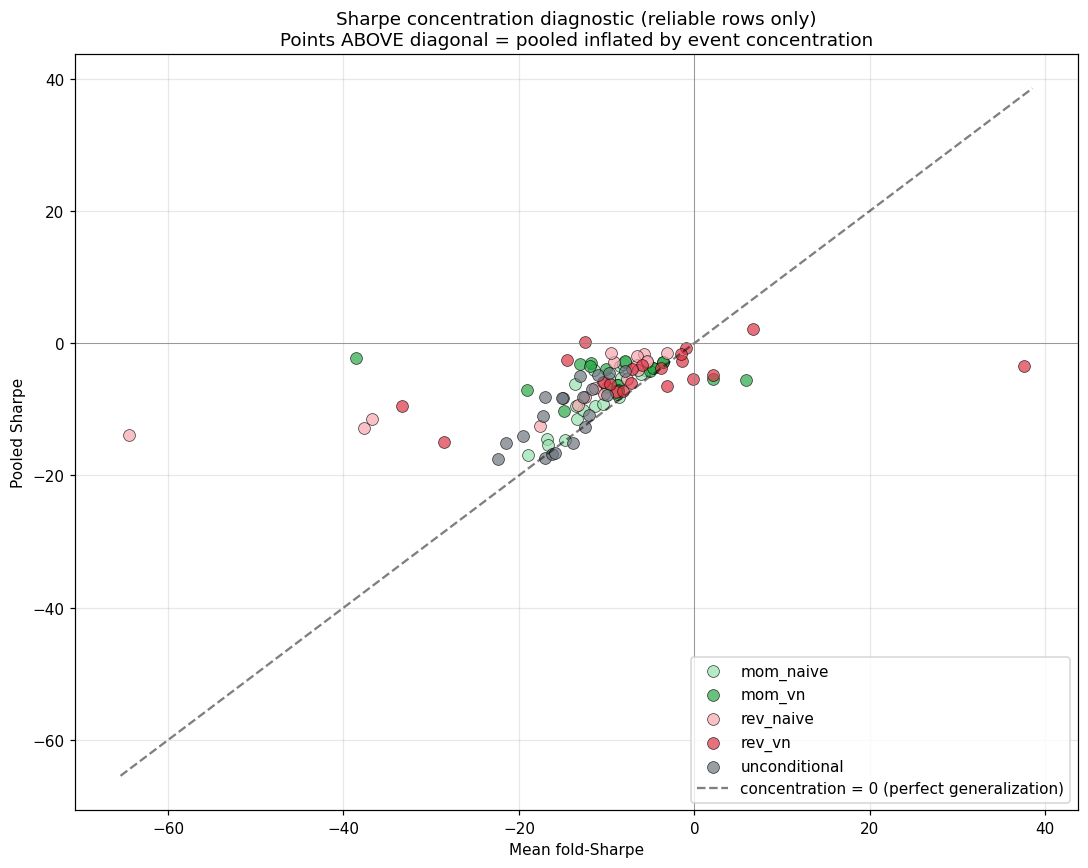

In [110]:
strat_colors = {
    'mom_vn': '#28A745', 'mom_naive': '#98E0AF',
    'rev_vn': '#DC3545', 'rev_naive': '#F7A7AE',
    'unconditional': '#6c757d'
}

df_scatter = p2_by_cat[p2_by_cat.sharpe_reliable == True].copy() if 'sharpe_reliable' in p2_by_cat else p2_by_cat.copy()

fig, ax = plt.subplots(figsize=(10, 8))
for strat in df_scatter['strategy'].unique():
    sub = df_scatter[df_scatter['strategy'] == strat]
    ax.scatter(sub['mean_fold_sharpe'], sub['pooled_sharpe_annualized'],
               label=strat, color=strat_colors.get(strat, '#888'),
               s=60, alpha=0.7, edgecolors='black', linewidths=0.5)

lims = [df_scatter[['mean_fold_sharpe','pooled_sharpe_annualized']].min().min() - 1,
        df_scatter[['mean_fold_sharpe','pooled_sharpe_annualized']].max().max() + 1]
ax.plot(lims, lims, 'k--', alpha=0.5, label='concentration = 0 (perfect generalization)')
ax.axhline(0, color='gray', linewidth=0.5); ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Mean fold-Sharpe')
ax.set_ylabel('Pooled Sharpe')
ax.set_title('Sharpe concentration diagnostic (reliable rows only)\n'
             'Points ABOVE diagonal = pooled inflated by event concentration')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

### 3.3 Chart 6 — Equity curves per strategy

P&L-over-time for each time horizon: A strategy with real edge should show consistent upward drift. Event-concentrated "edge" shows one big jump surrounded by flat or downward periods.

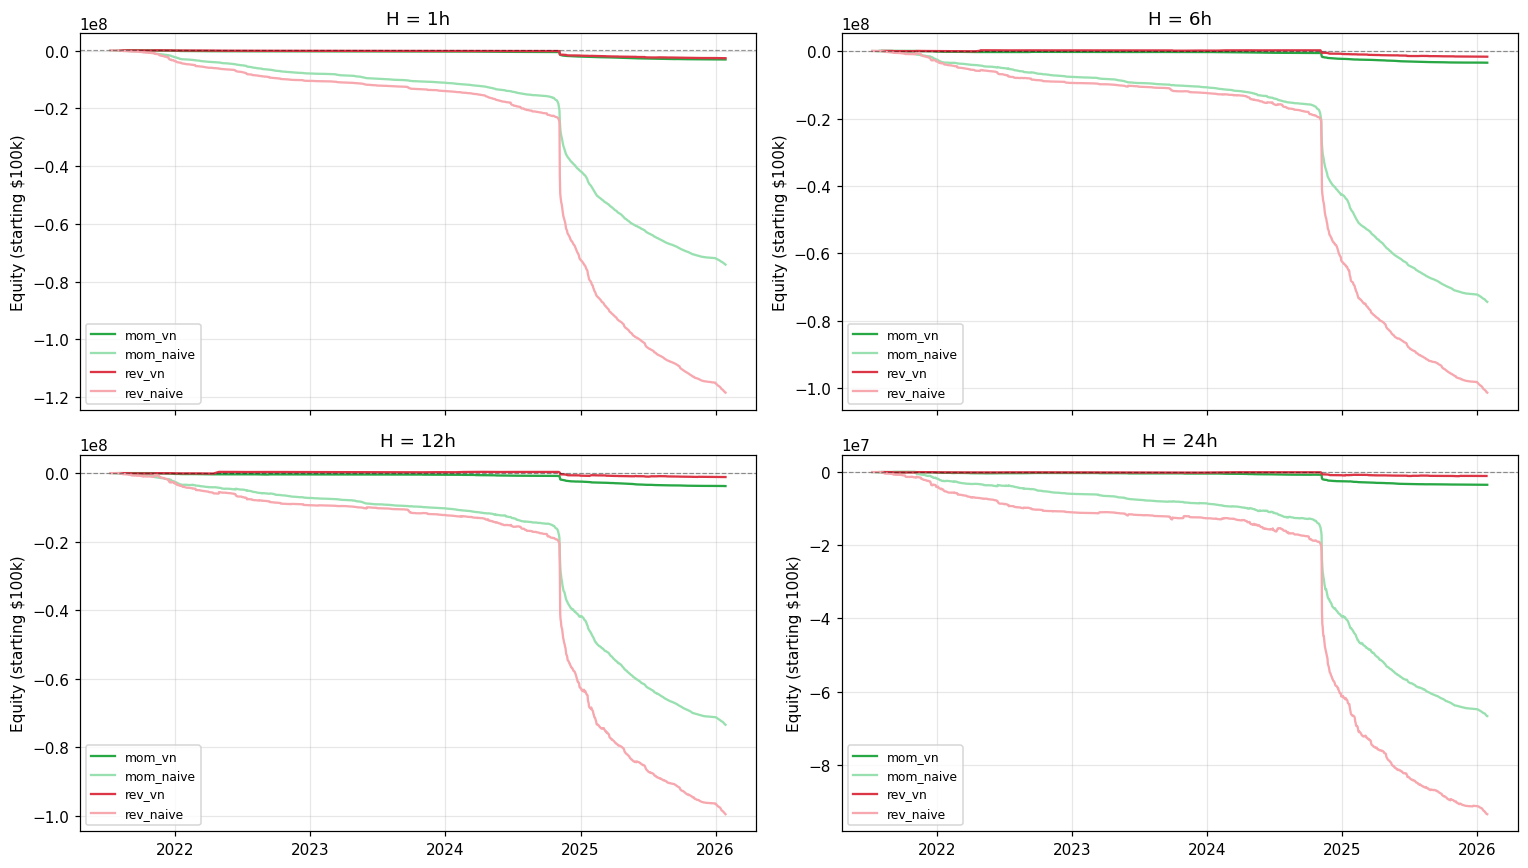

In [111]:
if p2_trades is not None:
    BANKROLL = 100_000.0
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    for ax, H in zip(axes.flatten(), [1, 6, 12, 24]):
        for strat in ['mom_vn', 'mom_naive', 'rev_vn', 'rev_naive']:
            sub = p2_trades[(p2_trades.strategy == strat) & (p2_trades.horizon_hours == H)].copy()
            if sub.empty:
                continue
            sub['exit_date'] = pd.to_datetime(sub.exit_ts).dt.floor('D')
            daily = sub.groupby('exit_date')['net_pnl'].sum().sort_index()
            equity = BANKROLL + daily.cumsum()
            ax.plot(equity.index, equity.values, label=strat, color=strat_colors.get(strat, '#888'), linewidth=1.5)
        ax.axhline(BANKROLL, color='k', linestyle='--', alpha=0.4, linewidth=0.8)
        ax.set_title(f'H = {H}h')
        ax.set_ylabel('Equity (starting $100k)')
        ax.legend(loc='best', fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print('Trade log unavailable — skipping equity curves.')

### 3.4 Chart 7 — Drawdown paths for the best strategies


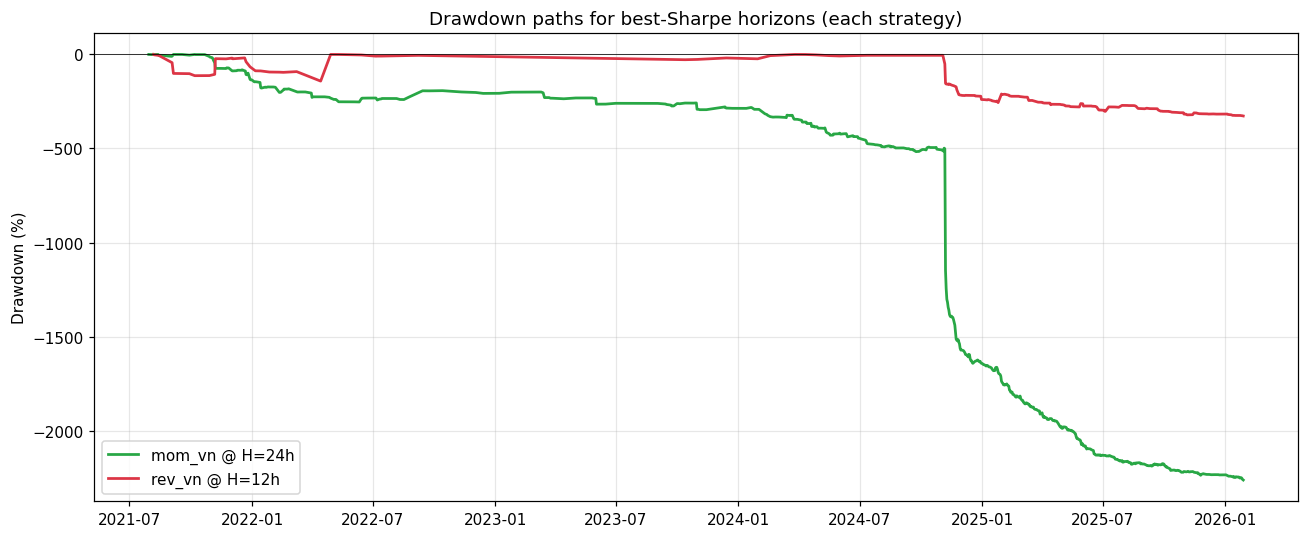

In [112]:
if p2_trades is not None:
    fig, ax = plt.subplots(figsize=(12, 5))
    for strat in ['mom_vn', 'rev_vn']:
        # pick H with best pooled Sharpe for this strategy
        best_H = p2_overall[p2_overall.strategy == strat].sort_values('daily_sharpe_annualized', ascending=False).iloc[0]['horizon_hours']
        sub = p2_trades[(p2_trades.strategy == strat) & (p2_trades.horizon_hours == best_H)].copy()
        if sub.empty:
            continue
        sub['exit_date'] = pd.to_datetime(sub.exit_ts).dt.floor('D')
        daily = sub.groupby('exit_date')['net_pnl'].sum().sort_index()
        equity = BANKROLL + daily.cumsum()
        drawdown = (equity - equity.cummax()) / equity.cummax() * 100
        ax.plot(drawdown.index, drawdown.values, label=f'{strat} @ H={int(best_H)}h',
                color=strat_colors.get(strat, '#888'), linewidth=1.8)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_ylabel('Drawdown (%)')
    ax.set_title('Drawdown paths for best-Sharpe horizons (each strategy)')
    ax.legend()
    plt.tight_layout(); plt.show()

### 3.5 Chart 8 — By-category deep dive

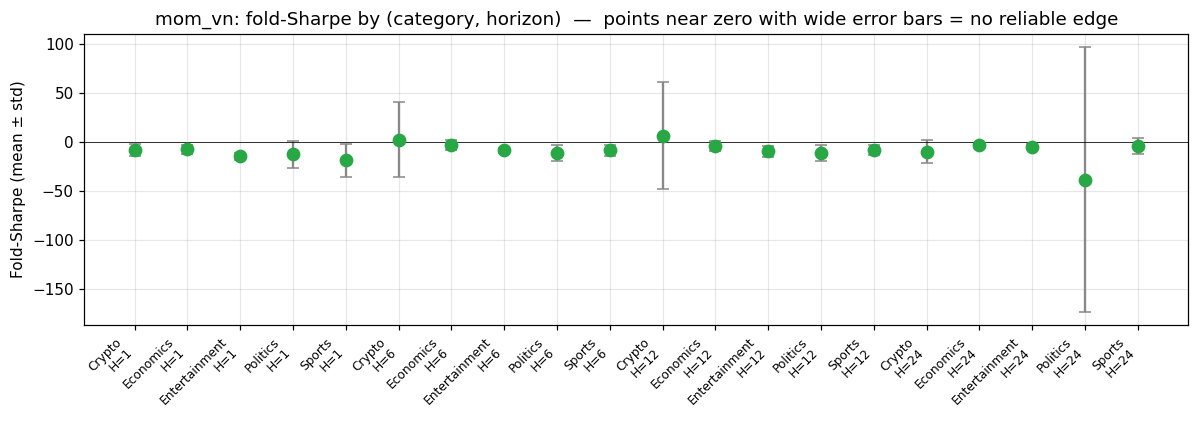

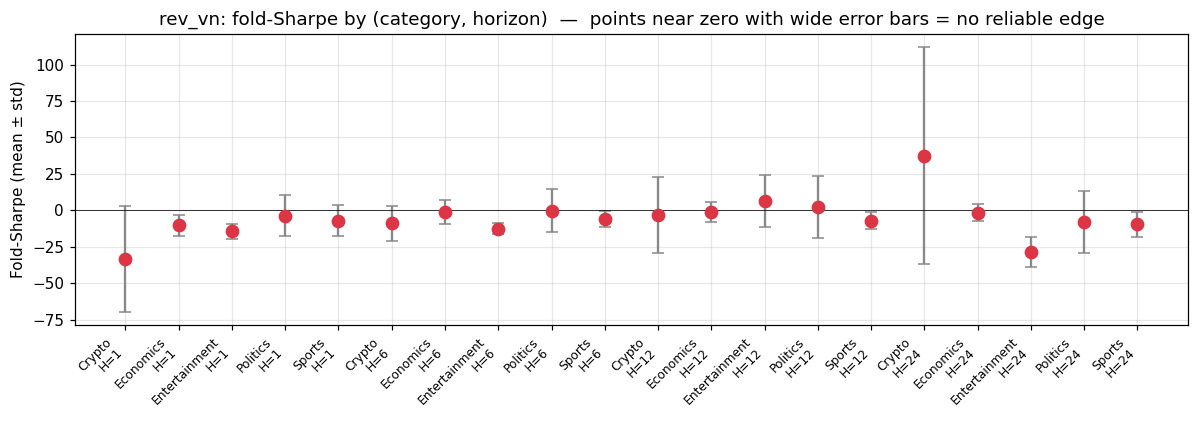

In [113]:
# Focus on the vol-normalized strategies (the ones we care about most)
for strat in ['mom_vn', 'rev_vn']:
    fig, ax = plt.subplots(figsize=(11, 4))
    sub = p2_by_cat[p2_by_cat.strategy == strat].copy()
    if sub.empty:
        continue
    # Points with error bars
    labels = []
    means = []
    stds = []
    for _, row in sub.iterrows():
        labels.append(f'{row["category"]}\nH={int(row["horizon_hours"])}')
        means.append(row['mean_fold_sharpe'] if pd.notna(row['mean_fold_sharpe']) else 0)
        stds.append(row['std_fold_sharpe'] if pd.notna(row['std_fold_sharpe']) else 0)
    x = np.arange(len(labels))
    ax.errorbar(x, means, yerr=stds, fmt='o', color=strat_colors.get(strat, '#888'),
                ecolor='#888', capsize=4, markersize=8, elinewidth=1.5)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Fold-Sharpe (mean ± std)')
    ax.set_title(f'{strat}: fold-Sharpe by (category, horizon)  —  '
                 f'points near zero with wide error bars = no reliable edge')
    plt.tight_layout(); plt.show()

### 3.6 Chart 9 — Sharpe vs turnover (fee efficiency)

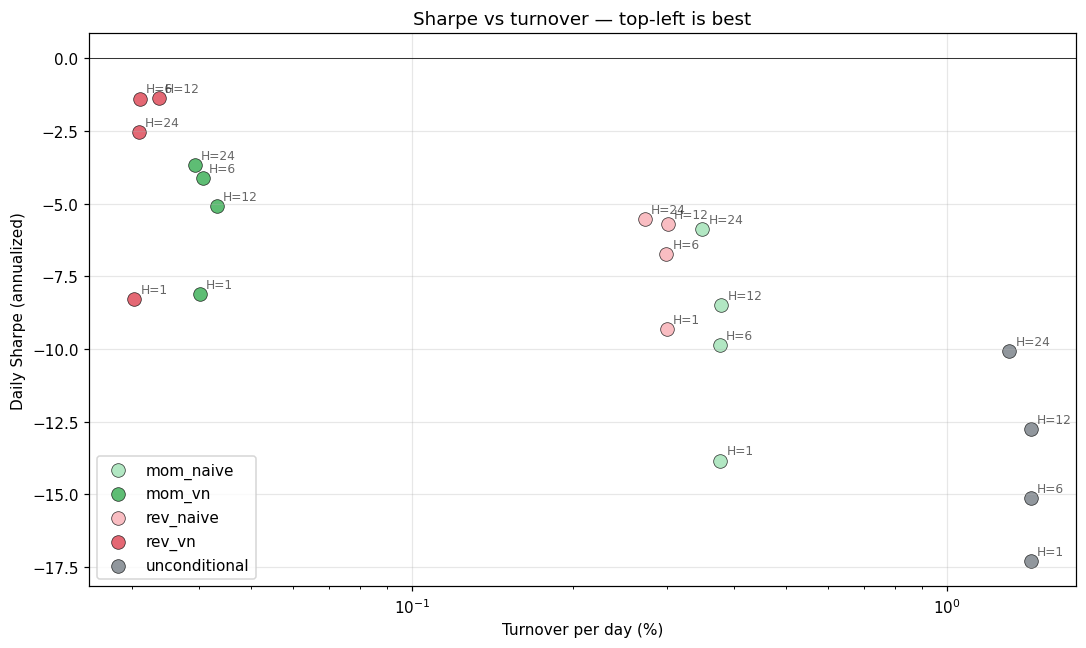

In [114]:
fig, ax = plt.subplots(figsize=(10, 6))
for strat in p2_overall['strategy'].unique():
    sub = p2_overall[p2_overall['strategy'] == strat]
    ax.scatter(sub['turnover_pct_per_day'], sub['daily_sharpe_annualized'],
               label=strat, color=strat_colors.get(strat, '#888'),
               s=80, alpha=0.75, edgecolors='black', linewidths=0.5)
    for _, row in sub.iterrows():
        ax.annotate(f'H={int(row.horizon_hours)}', (row.turnover_pct_per_day, row.daily_sharpe_annualized),
                    fontsize=8, xytext=(4, 4), textcoords='offset points', alpha=0.6)
ax.set_xscale('log')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Turnover per day (%)')
ax.set_ylabel('Daily Sharpe (annualized)')
ax.set_title('Sharpe vs turnover — top-left is best')
ax.legend(loc='best')
plt.tight_layout(); plt.show()

### 3.7 Phase 2 takeaways

---
## 4. Overall Interpretation

**What this project set out to do:**

**What it found:**

**Limitations:**

**Future Considerations:**